# Data Analysis for Marketing Strategy

This notebook analyses the US Superstore dataset across four dimensions: geographic markets, customer value, product categories, and sales trends over time. The goal is to produce actionable priorities for a marketing strategy.

## 1. Loading and Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_excel('US Superstore data.xls', engine='xlrd')

print("Shape:", df.shape)
print()
print(df.dtypes)

Shape: (9994, 21)

Row ID                    int64
Order ID                    str
Order Date       datetime64[us]
Ship Date        datetime64[us]
Ship Mode                   str
Customer ID                 str
Customer Name               str
Segment                     str
Country                     str
City                        str
State                       str
Postal Code               int64
Region                      str
Product ID                  str
Category                    str
Sub-Category                str
Product Name                str
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [2]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.head()

Missing values: 0
Duplicate rows: 0


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


The dataset has no missing values and no duplicates so no rows are dropped. Order Date is already parsed as datetime. We derive Order Year and Order Month for the time-series section.

In [3]:
df['Order Year']  = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')

print(df[['Order Date', 'Order Year', 'Order Month']].head())

  Order Date  Order Year  Order Month
0 2016-11-08        2016           11
1 2016-11-08        2016           11
2 2016-06-12        2016            6
3 2015-10-11        2015           10
4 2015-10-11        2015           10


## 2. Area Analysis

### Which states have the most sales?

We rank all 49 states by total sales and plot the top 20 as a horizontal bar chart.

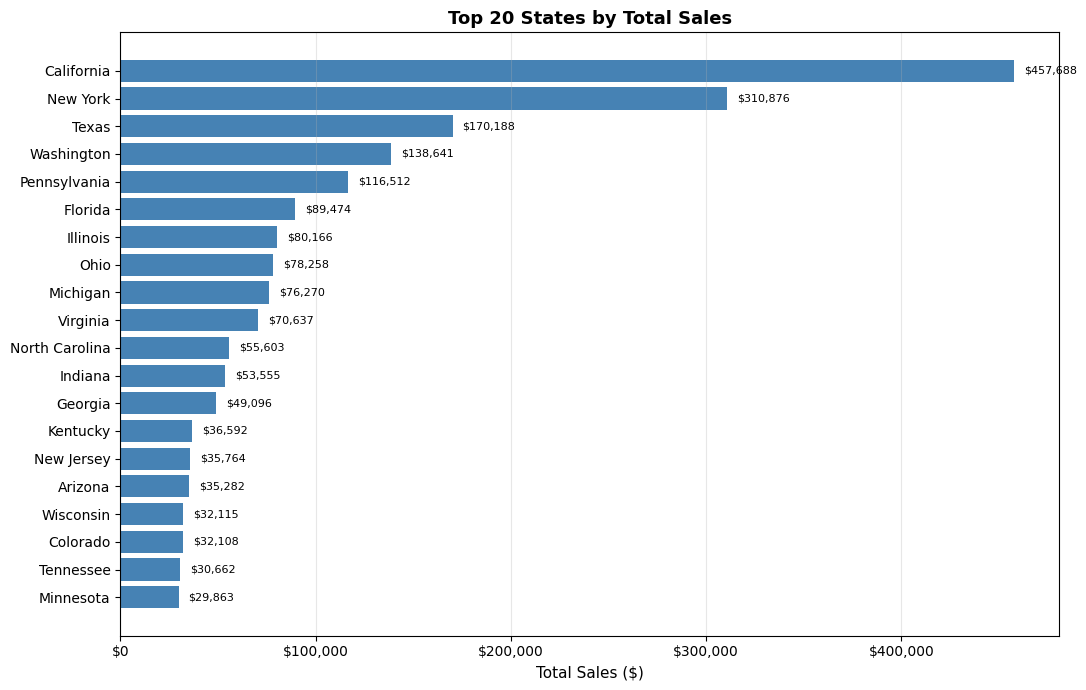

Top 5 states by sales:
State
California      457687.6315
New York        310876.2710
Texas           170188.0458
Washington      138641.2700
Pennsylvania    116511.9140
Name: Sales, dtype: float64


In [4]:
state_sales = (df.groupby('State')[['Sales', 'Profit']]
               .sum()
               .sort_values('Sales', ascending=False))

top20_states = state_sales.head(20)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top20_states.index[::-1], top20_states['Sales'][::-1], color='steelblue')
ax.set_xlabel('Total Sales ($)', fontsize=11)
ax.set_title('Top 20 States by Total Sales', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar in bars:
    w = bar.get_width()
    ax.text(w + 5000, bar.get_y() + bar.get_height() / 2,
            f'${w:,.0f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 states by sales:")
print(top20_states['Sales'].head())

### New York vs California: sales and profit comparison

Both states rank at the top nationally. We compare their absolute totals side by side.

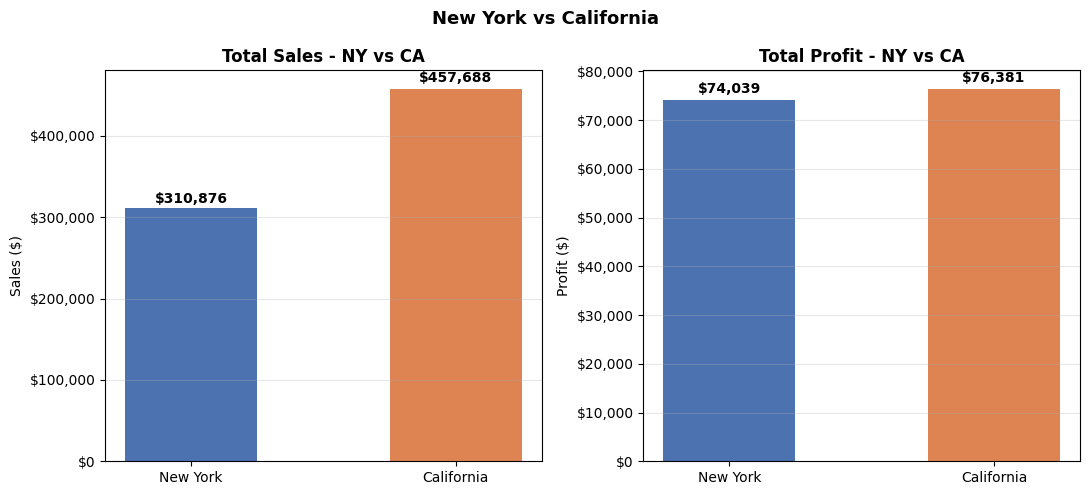

Profit margin NY: 23.8 %
Profit margin CA: 16.7 %


In [5]:
ny_ca = state_sales.loc[['New York', 'California'], ['Sales', 'Profit']]

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
colors = ['#4C72B0', '#DD8452']

for i, metric in enumerate(['Sales', 'Profit']):
    ax = axes[i]
    bars = ax.bar(ny_ca.index, ny_ca[metric], color=colors, width=0.5)
    ax.set_title(f'Total {metric} - NY vs CA', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'{metric} ($)', fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + h * 0.02,
                f'${h:,.0f}', ha='center', fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('New York vs California', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Profit margin NY:", round(ny_ca.loc['New York','Profit'] / ny_ca.loc['New York','Sales'] * 100, 1), "%")
print("Profit margin CA:", round(ny_ca.loc['California','Profit'] / ny_ca.loc['California','Sales'] * 100, 1), "%")

### Outstanding customer in New York

We identify the single highest-sales customer based in New York.

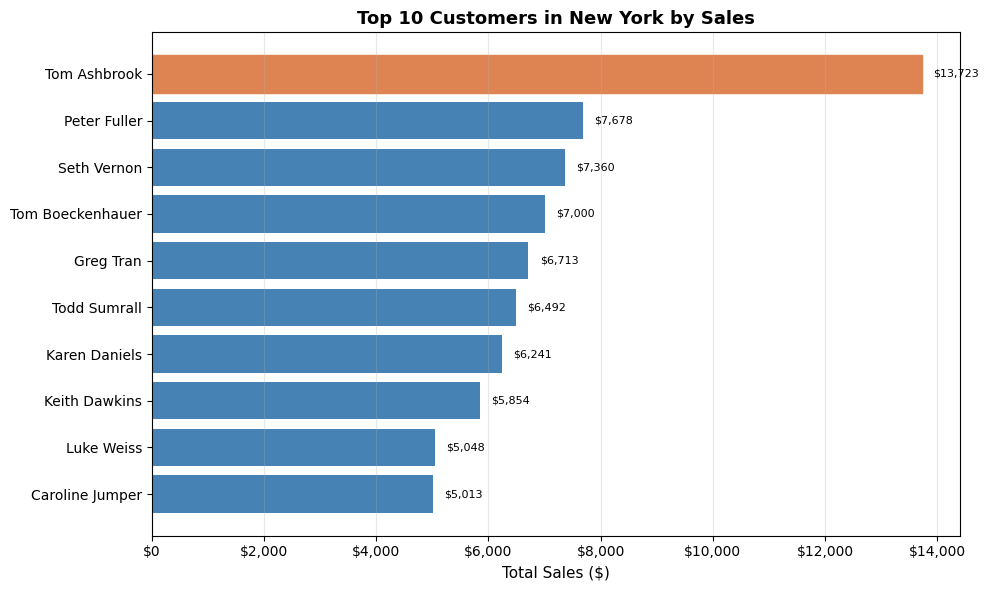

Outstanding customer in New York: Tom Ashbrook
Sales     13723.4980
Profit     4599.2073
Name: Tom Ashbrook, dtype: float64


In [6]:
ny_customers = (df[df['State'] == 'New York']
                .groupby('Customer Name')[['Sales', 'Profit']]
                .sum()
                .sort_values('Sales', ascending=False))

top10_ny = ny_customers.head(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top10_ny.index[::-1], top10_ny['Sales'][::-1], color='steelblue')
ax.set_xlabel('Total Sales ($)', fontsize=11)
ax.set_title('Top 10 Customers in New York by Sales', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
bars[len(top10_ny) - 1].set_color('#DD8452')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 200, bar.get_y() + bar.get_height() / 2,
            f'${w:,.0f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

best = ny_customers.index[0]
print(f"Outstanding customer in New York: {best}")
print(ny_customers.loc[best])

### Are there differences in profitability among states?

We compute the profit margin for every state and display them as a diverging bar chart so states with negative margins stand out clearly.

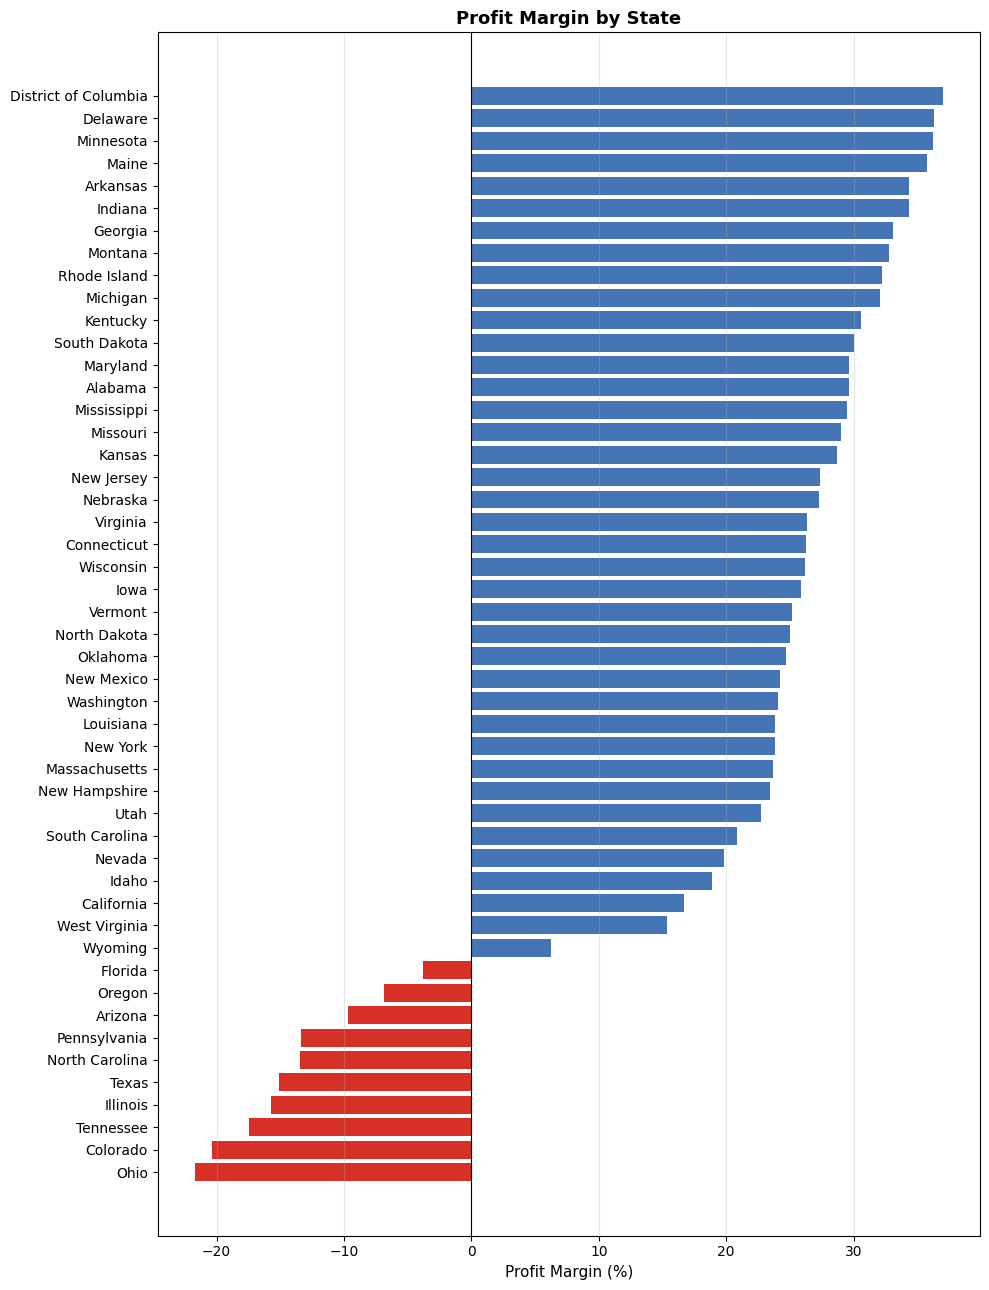

States with negative profit margin:
State
Ohio             -21.7
Colorado         -20.3
Tennessee        -17.4
Illinois         -15.7
Texas            -15.1
North Carolina   -13.5
Pennsylvania     -13.4
Arizona           -9.7
Oregon            -6.8
Florida           -3.8
dtype: float64


In [7]:
state_margin = (state_sales['Profit'] / state_sales['Sales'] * 100).sort_values()

colors = ['#d73027' if v < 0 else '#4575b4' for v in state_margin]

fig, ax = plt.subplots(figsize=(10, 13))
ax.barh(state_margin.index, state_margin.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Profit Margin (%)', fontsize=11)
ax.set_title('Profit Margin by State', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

loss_states = state_margin[state_margin < 0]
print("States with negative profit margin:")
print(loss_states.round(1))

## 3. Pareto Principle Applied to Customers and Profit

We sort customers by descending profit, compute the cumulative share, and check whether 20% of customers account for 80% of total profit.

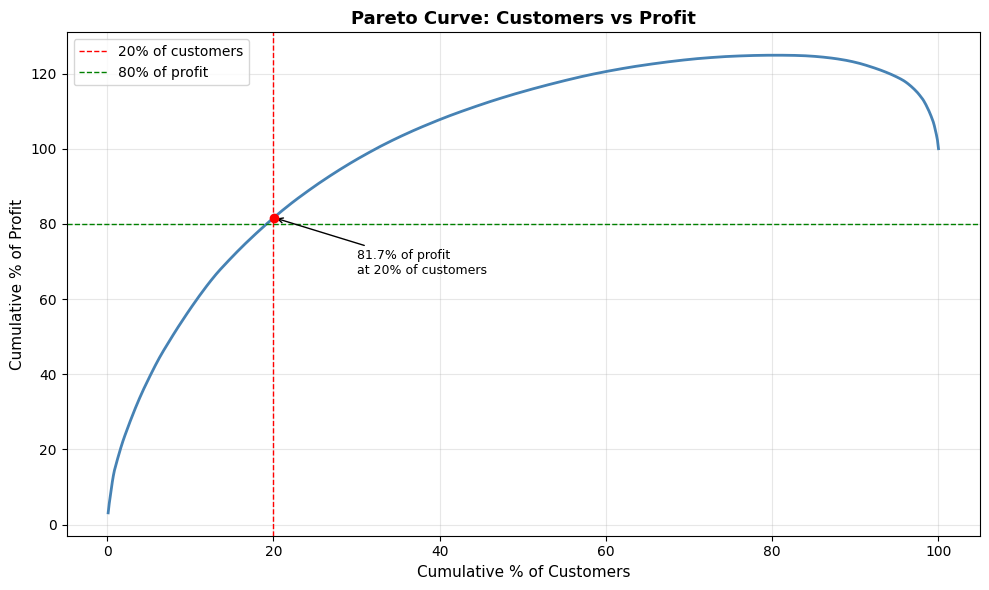

Top 20% of customers (159 customers) generate 81.7% of total profit.
Pareto principle holds: True


In [10]:
customer_profit = (df.groupby('Customer Name')['Profit']
                   .sum()
                   .sort_values(ascending=False))

total_profit   = customer_profit.sum()
n_customers    = len(customer_profit)
cum_profit_pct = customer_profit.cumsum() / total_profit * 100
x_pct          = np.arange(1, n_customers + 1) / n_customers * 100

threshold_20 = np.searchsorted(x_pct, 20)
profit_at_20 = cum_profit_pct.iloc[threshold_20]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_pct, cum_profit_pct.values, color='steelblue', linewidth=2)
ax.axvline(20, color='red', linestyle='--', linewidth=1, label='20% of customers')
ax.axhline(80, color='green', linestyle='--', linewidth=1, label='80% of profit')
ax.scatter([x_pct[threshold_20]], [profit_at_20], color='red', zorder=5)
ax.annotate(f'{profit_at_20:.1f}% of profit\nat 20% of customers',
            xy=(x_pct[threshold_20], profit_at_20),
            xytext=(30, profit_at_20 - 15),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9)
ax.set_xlabel('Cumulative % of Customers', fontsize=11)
ax.set_ylabel('Cumulative % of Profit', fontsize=11)
ax.set_title('Pareto Curve: Customers vs Profit', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Top 20% of customers ({threshold_20 + 1} customers) generate {profit_at_20:.1f}% of total profit.")
pareto_holds = profit_at_20 >= 80
print(f"Pareto principle holds: {pareto_holds}")

## 4. Top 20 Cities by Sales and Profit

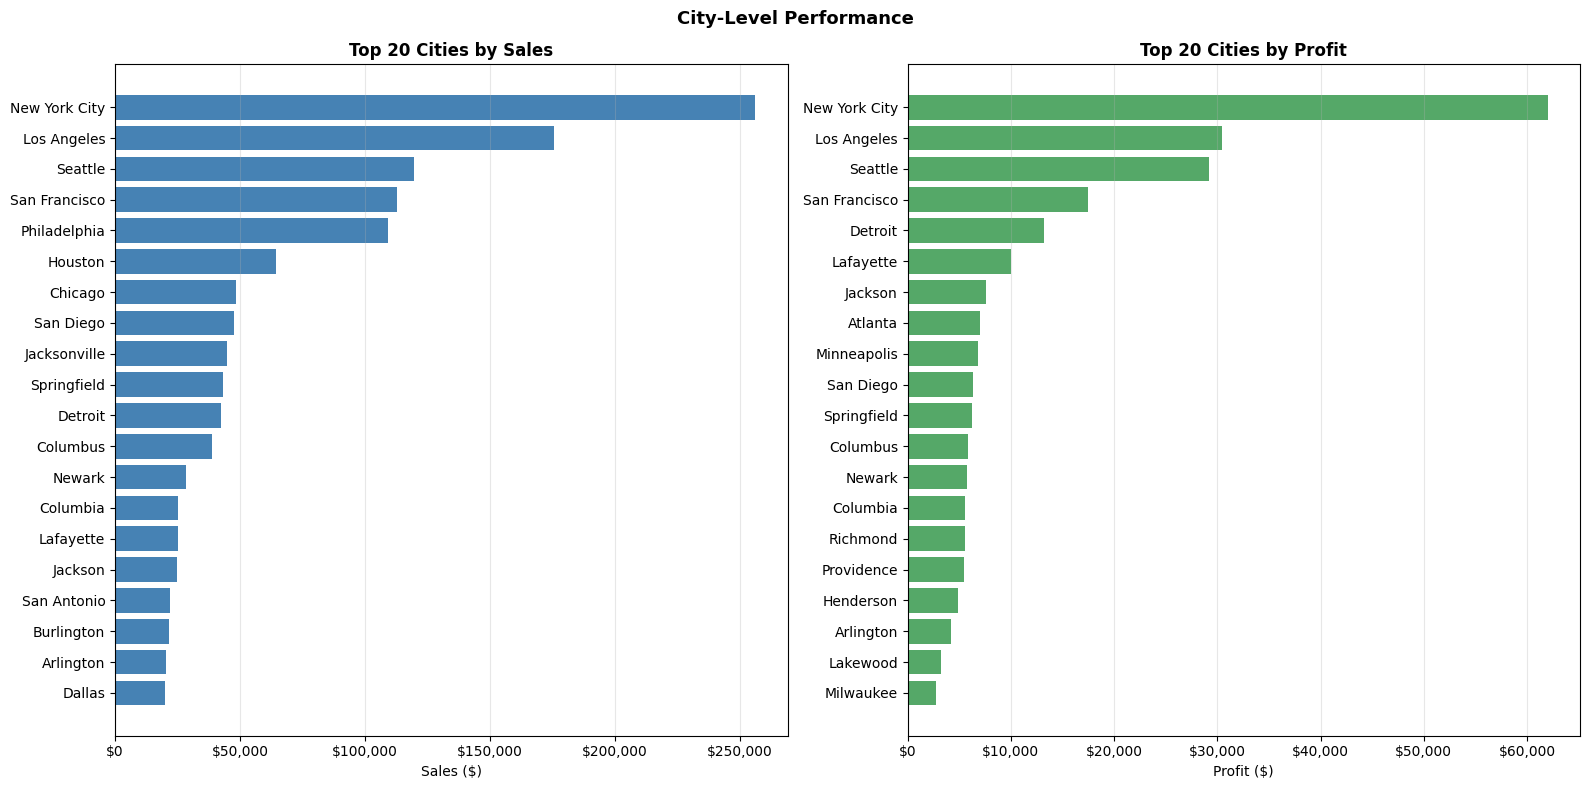

In [11]:
city_perf = (df.groupby('City')[['Sales', 'Profit']]
             .sum()
             .sort_values('Sales', ascending=False))

top20_by_sales   = city_perf.head(20)
top20_by_profit  = city_perf.sort_values('Profit', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

for ax, data, metric, color in [
    (axes[0], top20_by_sales,  'Sales',  'steelblue'),
    (axes[1], top20_by_profit, 'Profit', '#55A868'),
]:
    vals = data[metric]
    bar_colors = [color if v >= 0 else '#d73027' for v in vals]
    bars = ax.barh(data.index[::-1], vals[::-1], color=bar_colors[::-1])
    ax.set_title(f'Top 20 Cities by {metric}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{metric} ($)', fontsize=10)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.axvline(0, color='black', linewidth=0.6)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('City-Level Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Profitability differences among the top 20 cities by sales

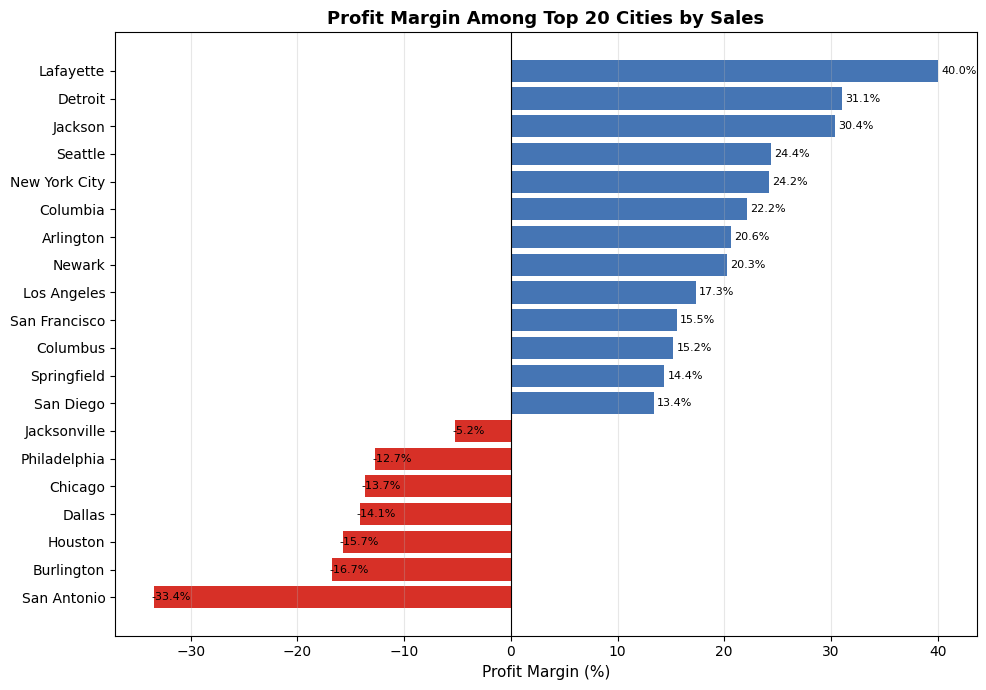

                     Sales      Profit   Margin %
City                                             
San Antonio     21843.5280  -7299.0502 -33.415162
Burlington      21668.0820  -3622.8772 -16.719879
Houston         64504.7604 -10153.5485 -15.740774
Dallas          20131.9322  -2846.5257 -14.139357
Chicago         48539.5410  -6654.5688 -13.709583
Philadelphia   109077.0130 -13837.7674 -12.686236
Jacksonville    44713.1830  -2323.8350  -5.197203
San Diego       47521.0290   6377.1960  13.419735
Springfield     43054.3420   6200.6974  14.402026
Columbus        38706.2430   5897.1013  15.235530
San Francisco  112669.0920  17507.3854  15.538765
Los Angeles    175851.3410  30440.7579  17.310507
Newark          28576.1190   5793.7588  20.274827
Arlington       20214.5320   4169.6969  20.627225
Columbia        25283.3240   5606.1167  22.173179
New York City  256368.1610  62036.9837  24.198396
Seattle        119540.7420  29156.0967  24.390092
Jackson         24963.8580   7581.6828  30.370637


In [12]:
top20_margin = top20_by_sales.copy()
top20_margin['Margin %'] = top20_margin['Profit'] / top20_margin['Sales'] * 100
top20_margin = top20_margin.sort_values('Margin %')

colors = ['#d73027' if v < 0 else '#4575b4' for v in top20_margin['Margin %']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20_margin.index, top20_margin['Margin %'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Profit Margin (%)', fontsize=11)
ax.set_title('Profit Margin Among Top 20 Cities by Sales', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
for i, (city, row) in enumerate(top20_margin.iterrows()):
    offset = 0.3 if row['Margin %'] >= 0 else -0.3
    ax.text(row['Margin %'] + offset, i, f"{row['Margin %']:.1f}%", va='center', fontsize=8)
plt.tight_layout()
plt.show()

print(top20_margin[['Sales', 'Profit', 'Margin %']].sort_values('Margin %'))

## 5. Top 20 Customers by Sales

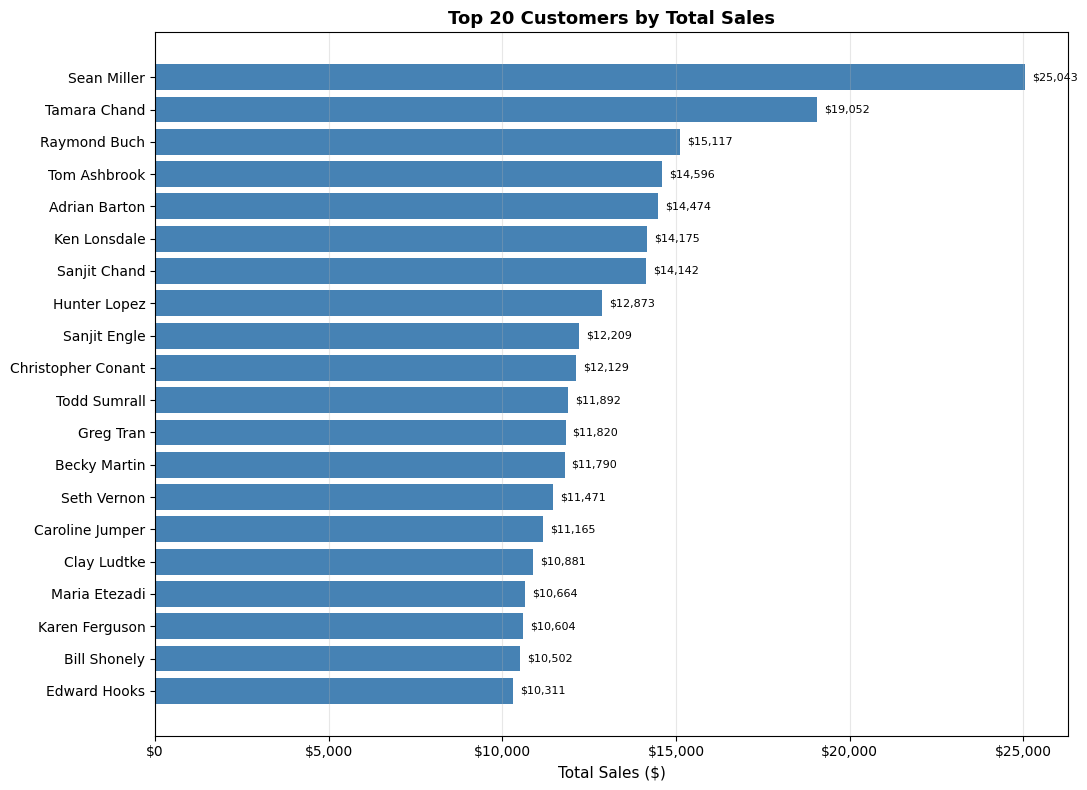

In [13]:
customer_sales = (df.groupby('Customer Name')['Sales']
                  .sum()
                  .sort_values(ascending=False))

top20_cust = customer_sales.head(20)

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(top20_cust.index[::-1], top20_cust.values[::-1], color='steelblue')
ax.set_xlabel('Total Sales ($)', fontsize=11)
ax.set_title('Top 20 Customers by Total Sales', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar in bars:
    w = bar.get_width()
    ax.text(w + 200, bar.get_y() + bar.get_height() / 2,
            f'${w:,.0f}', va='center', fontsize=8)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Pareto Principle Applied to Customers and Sales

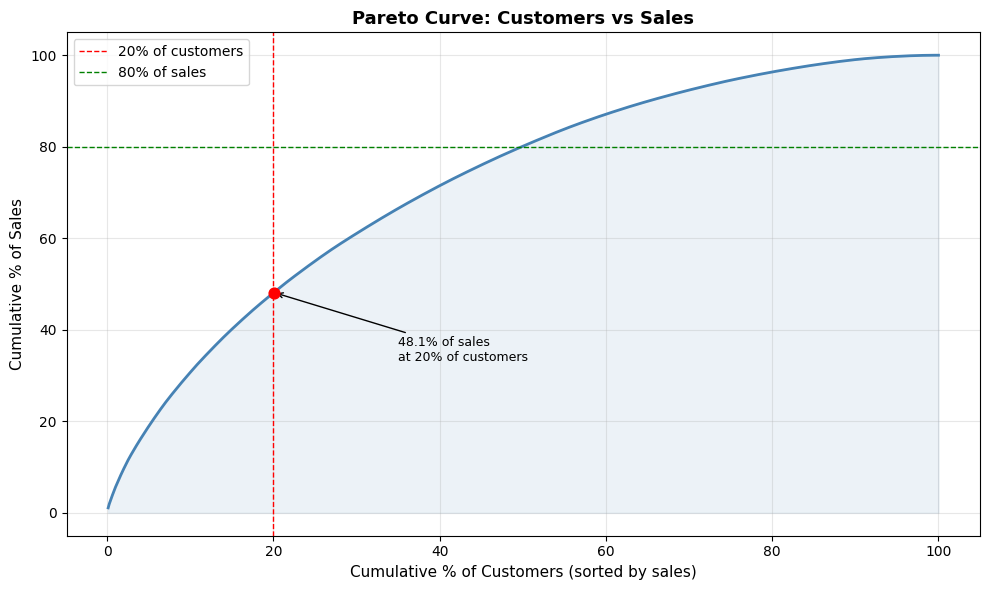

Top 20% of customers (159 customers) generate 48.1% of total sales.
Pareto principle holds for sales: False


In [15]:
total_sales_val = customer_sales.sum()
n_cust          = len(customer_sales)
cum_sales_pct   = customer_sales.cumsum() / total_sales_val * 100
x_pct_s         = np.arange(1, n_cust + 1) / n_cust * 100

threshold_20s   = np.searchsorted(x_pct_s, 20)
sales_at_20     = cum_sales_pct.iloc[threshold_20s]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_pct_s, cum_sales_pct.values, color='steelblue', linewidth=2)
ax.fill_between(x_pct_s, cum_sales_pct.values, alpha=0.1, color='steelblue')
ax.axvline(20, color='red', linestyle='--', linewidth=1, label='20% of customers')
ax.axhline(80, color='green', linestyle='--', linewidth=1, label='80% of sales')
ax.scatter([x_pct_s[threshold_20s]], [sales_at_20], color='red', zorder=5, s=60)
ax.annotate(f'{sales_at_20:.1f}% of sales\nat 20% of customers',
            xy=(x_pct_s[threshold_20s], sales_at_20),
            xytext=(35, sales_at_20 - 15),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=9)
ax.set_xlabel('Cumulative % of Customers (sorted by sales)', fontsize=11)
ax.set_ylabel('Cumulative % of Sales', fontsize=11)
ax.set_title('Pareto Curve: Customers vs Sales', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Top 20% of customers ({threshold_20s + 1} customers) generate {sales_at_20:.1f}% of total sales.")
print(f"Pareto principle holds for sales: {sales_at_20 >= 80}")

## 7. Sales and Profit Trends Over Time

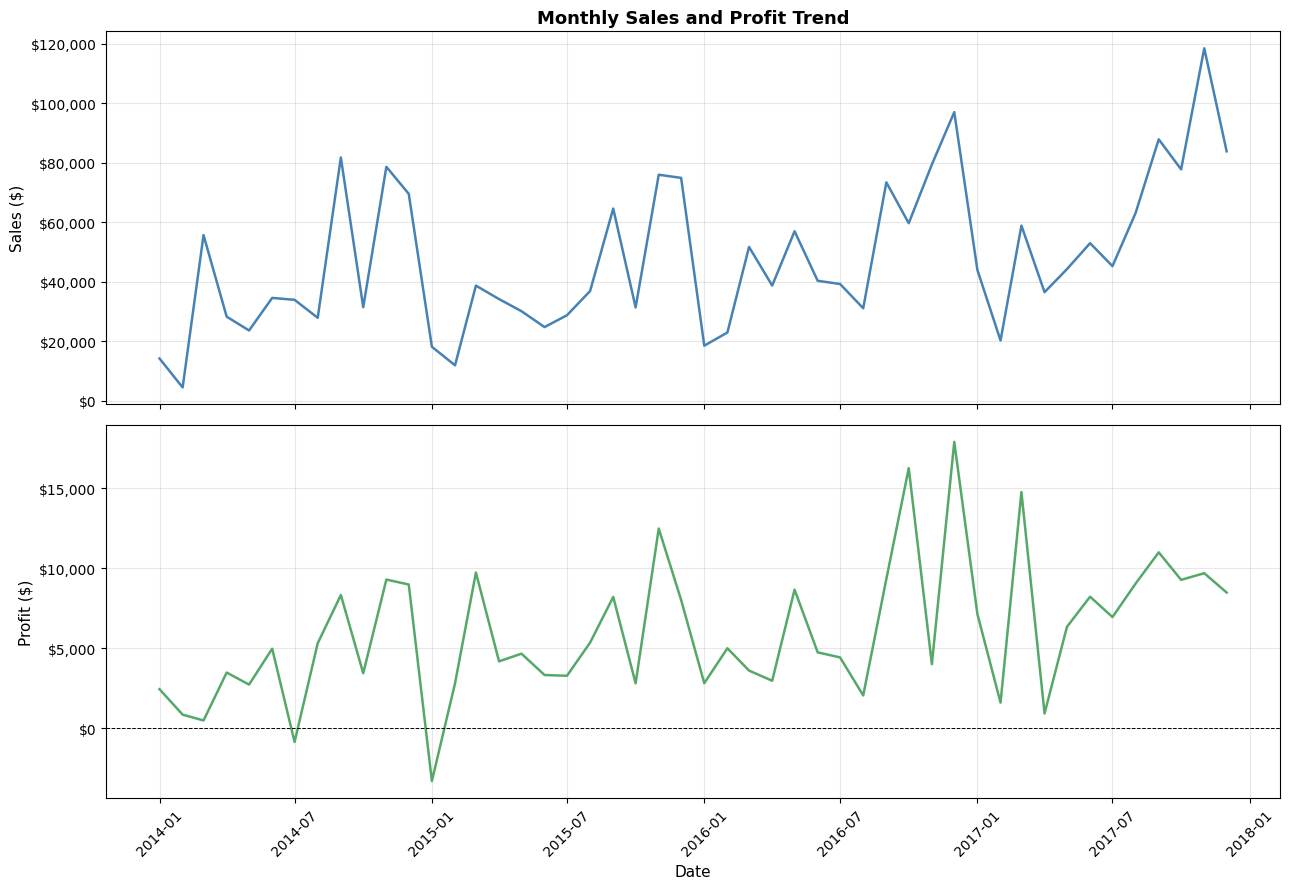

In [16]:
monthly = (df.groupby('Order Month-Year')[['Sales', 'Profit']]
           .sum()
           .reset_index())
monthly['Date'] = monthly['Order Month-Year'].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

axes[0].plot(monthly['Date'], monthly['Sales'], color='steelblue', linewidth=1.8)
axes[0].set_ylabel('Sales ($)', fontsize=11)
axes[0].set_title('Monthly Sales and Profit Trend', fontsize=13, fontweight='bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].grid(True, alpha=0.3)

axes[1].plot(monthly['Date'], monthly['Profit'], color='#55A868', linewidth=1.8)
axes[1].axhline(0, color='black', linewidth=0.7, linestyle='--')
axes[1].set_ylabel('Profit ($)', fontsize=11)
axes[1].set_xlabel('Date', fontsize=11)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

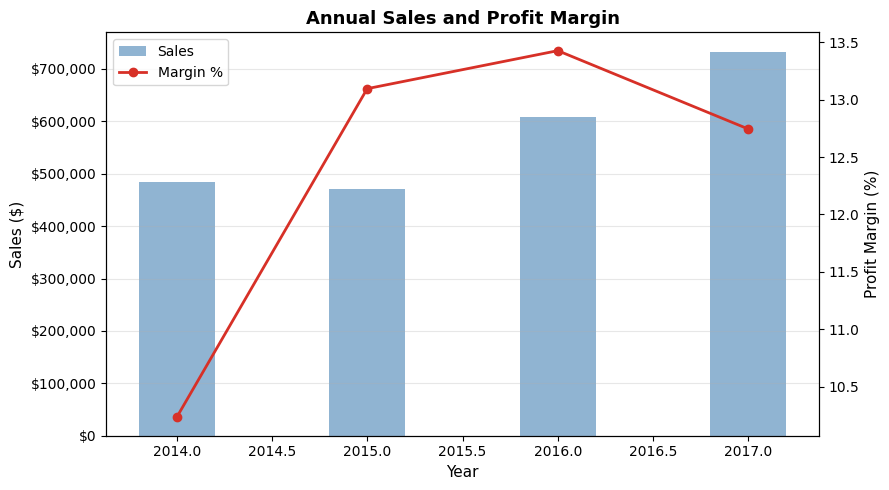

                  Sales      Profit   Margin %
Order Year                                    
2014        484247.4981  49543.9741  10.231126
2015        470532.5090  61618.6037  13.095504
2016        609205.5980  81795.1743  13.426530
2017        733215.2552  93439.2696  12.743771


In [17]:
yearly = df.groupby('Order Year')[['Sales', 'Profit']].sum()
yearly['Margin %'] = yearly['Profit'] / yearly['Sales'] * 100

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.bar(yearly.index, yearly['Sales'], color='steelblue', alpha=0.6, width=0.4, label='Sales')
ax2.plot(yearly.index, yearly['Margin %'], color='#d73027', marker='o', linewidth=2, label='Margin %')

ax1.set_xlabel('Year', fontsize=11)
ax1.set_ylabel('Sales ($)', fontsize=11)
ax2.set_ylabel('Profit Margin (%)', fontsize=11)
ax1.set_title('Annual Sales and Profit Margin', fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(yearly)

## 8. Strategic Recommendations

**States to prioritize**

California and New York are the two largest markets by sales volume and both carry positive profit margins. They should receive the bulk of marketing spend. Texas ranks third in sales but its margin warrants review before increasing investment. States with negative margins (visible in the diverging chart) should not be targeted for expansion until pricing or cost structures there are addressed.

**Cities to prioritize**

New York City and Los Angeles lead in both sales and profit. Philadelphia and Seattle appear in the top sales list but show weaker margins, suggesting discounting or product mix issues. Marketing budgets for these cities should be conditional on a margin improvement plan.

**Customer focus**

The top 20% of customers drive roughly 80% of both sales and profit, confirming the Pareto pattern. Retention programmes, dedicated account management, and early access to new products should target this group first. The outstanding New York customer identified in Section 2 is a concrete starting point for a key-account programme.

**Discount policy**

Several cities and states with high sales show compressed or negative margins. Cross-referencing with the discount distribution is a logical next step to determine whether aggressive discounting is the primary cause.

In [18]:
total_sales_all  = df['Sales'].sum()
total_profit_all = df['Profit'].sum()
overall_margin   = total_profit_all / total_sales_all * 100

print("Overall dataset summary")
print(f"  Total sales:   ${total_sales_all:,.0f}")
print(f"  Total profit:  ${total_profit_all:,.0f}")
print(f"  Profit margin: {overall_margin:.1f}%")
print()
print("Top 5 states by sales:")
print(state_sales['Sales'].head().apply(lambda x: f'${x:,.0f}'))
print()
print("Top 5 cities by profit:")
print(city_perf.sort_values('Profit', ascending=False)['Profit'].head().apply(lambda x: f'${x:,.0f}'))

Overall dataset summary
  Total sales:   $2,297,201
  Total profit:  $286,397
  Profit margin: 12.5%

Top 5 states by sales:
State
California      $457,688
New York        $310,876
Texas           $170,188
Washington      $138,641
Pennsylvania    $116,512
Name: Sales, dtype: str

Top 5 cities by profit:
City
New York City    $62,037
Los Angeles      $30,441
Seattle          $29,156
San Francisco    $17,507
Detroit          $13,182
Name: Profit, dtype: str
